# Credit Card Fraud Detection Using Machine Learning

## Project Overview

The objective of this project is to build and evaluate machine learning models capable of detecting fraudulent credit card transactions.

Because fraud detection datasets are highly imbalanced, special attention is given to data exploration, preprocessing, class balancing using SMOTE, and evaluation metrics beyond simple accuracy.

## Workflow

1. Imports
2. Data Exploration
3. Data Quality Assessment
4. Exploratory Data Analysis (EDA)
5. Data Preprocessing
6. Modeling Pipeline
7. Model Evaluation
8. Test Set Evaluation
9. Conclusion

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline 

## 2. Data Exploration

### Dataset

The dataset contains anonymized credit card transactions made by European cardholders.

Features:

- V1–V28: Principal components obtained using PCA
- Time: Seconds elapsed between transactions
- Amount: Transaction amount
- Class:
    - 0 → Legitimate Transaction
    - 1 → Fraudulent Transaction

The dataset is highly imbalanced, making fraud detection a challenging classification problem.

In [4]:
# Load the credit card transactions dataset
df = pd.read_csv('creditcard.csv')

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

## 3. Data Quality Assessment

In [10]:
print(f"Shape: {df.shape}")
print(f"Fraud %: {df['Class'].mean()*100:.3f}%")
print(df['Class'].value_counts())

Shape: (284807, 31)
Fraud %: 0.173%
Class
0    284315
1       492
Name: count, dtype: int64


#### Observation

Only **0.173%** of the transactions are fraudulent.

This confirms that the dataset is **highly imbalanced**, making accuracy an unreliable evaluation metric.

For this reason, precision, recall, F1-score, ROC-AUC, and Precision-Recall AUC will be emphasized later in the project.

In [11]:
# Check for missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
# Check for duplicate records
duplicates = df.duplicated().sum()
print(f"Duplicate Records: {duplicates}")

# Remove duplicate records
df.drop_duplicates(inplace=True)

Duplicate Records: 1081


## 4. Exploratory Data Analysis (EDA)

This section explores the dataset to better understand feature distributions, class imbalance, and relationships between variables. These insights help guide preprocessing and model selection.

#### Observations

- Transaction amounts are highly right-skewed, with most transactions involving relatively small amounts.
- A small number of transactions have very large amounts, indicating the presence of outliers.
- Transaction time is spread across the observation period and does not appear uniformly distributed.

Text(0.5, 0, 'Transaction Class')

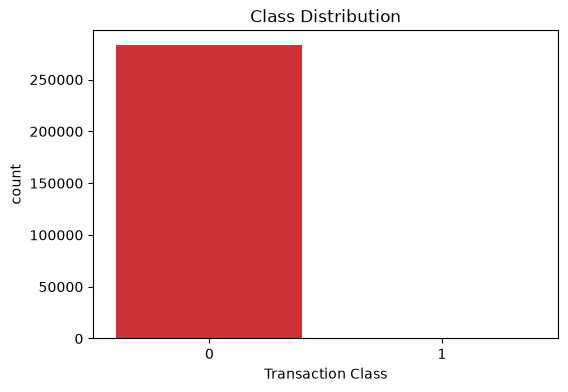

In [13]:
# Visualize the distribution of legitimate and fraudulent transactions
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df, palette='Set1')
plt.title("Class Distribution")
plt.xlabel("Transaction Class")

#### Observation

The dataset is extremely imbalanced. Fraudulent transactions account for only about **0.17%** of all observations. Therefore, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC are more appropriate than accuracy.

([<matplotlib.axis.XTick at 0x2aad5161d10>,
 [Text(0, 0, 'Legitimate'), Text(1, 0, 'Fraud')])

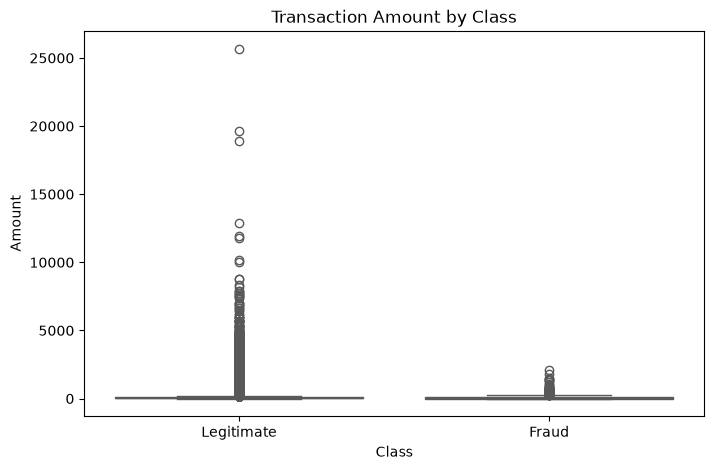

In [14]:
# Compare transaction amounts for legitimate and fraudulent transactions
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="Amount", data=df, palette='Set2')
plt.title("Transaction Amount by Class")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

(0.0, 172792.0)

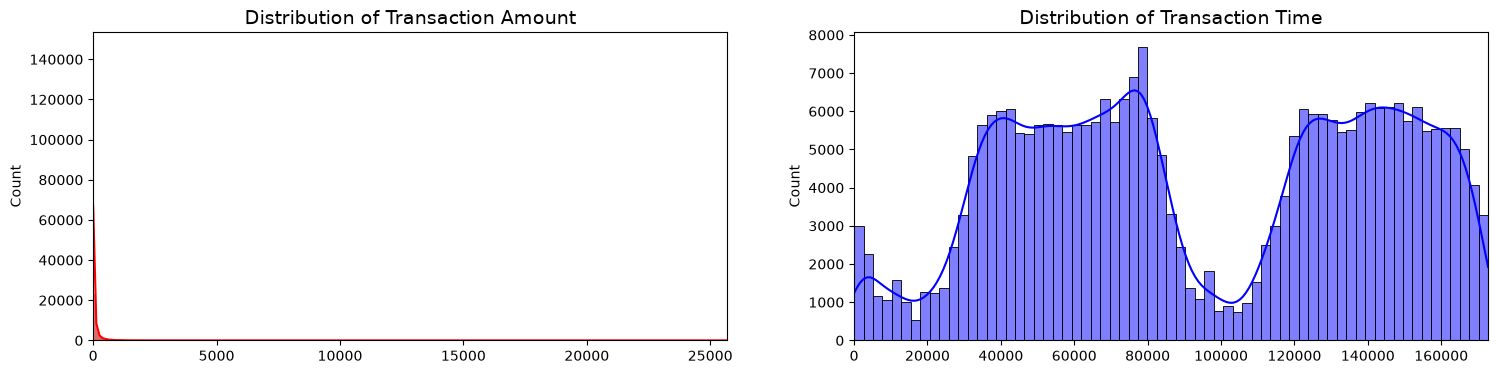

In [15]:
# Create two subplots to visualize the distributions of transaction amount and transaction time
fig, ax = plt.subplots(1, 2, figsize=(18,4))

# The amount and time features
amount_val = df['Amount'].values
time_val = df['Time'].values

# Transaction amount distribution
sns.histplot(amount_val, ax=ax[0], color='r', kde=True)
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

# Transaction time distribution
sns.histplot(time_val, ax=ax[1], color='b', kde=True)
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])

Text(0.5, 1.0, 'Feature Correlation Matrix')

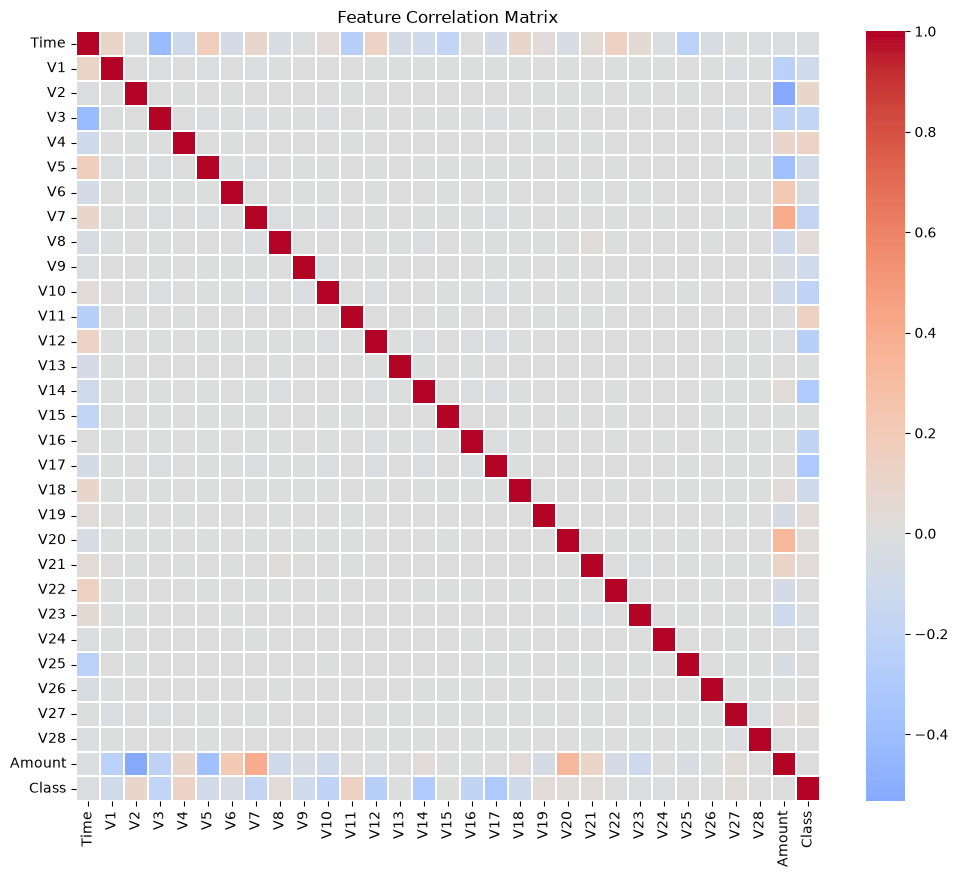

In [16]:
# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Feature Correlation Matrix")

## 5. Data Preprocessing

In [17]:
# Features & target
X = df.drop('Class', axis=1)
y = df['Class']

# Train/Test split (stratified to preserve imbalance ratio) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # ← important for imbalanced data
)

In [18]:
print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (226980, 30), Test shape: (56746, 30)


## 6. Modeling Pipeline

In [19]:
# Pipeline 1: Logistic Regression + SMOTE
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('smote', SMOTE(random_state=42)), # only runs on training data
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])


In [20]:
# Pipeline 2: Random Forest + SMOTE
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [21]:
# Pipeline 3: XGBoost (handles imbalance with scale_pos_weight)
fraud_count = (y_train == 0).sum() / (y_train == 1).sum()  # ratio

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        scale_pos_weight=fraud_count,
        n_estimators=200,
        learning_rate=0.05,
        use_label_encoder=False,
        eval_metric='aucpr',       # area under PR curve — best for imbalance
        random_state=42,
        n_jobs=-1
    ))
])

In [22]:
models = {
    'Logistic Regression + SMOTE': lr_pipeline,
    'Random Forest + SMOTE':       rf_pipeline,
    'XGBoost + SMOTE':             xgb_pipeline,
}

## 7. Model Evaluation

### Cross-Validation

To compare the performance of the candidate models, **3-fold Stratified Cross-Validation** is performed on the training set.

Since fraudulent transactions represent only a small fraction of the dataset, **Average Precision (PR-AUC)** is selected as the primary evaluation metric. PR-AUC provides a more informative assessment than accuracy when dealing with highly imbalanced classification problems.

In [23]:
# Cross-Validation on all models (train set only) 
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_results = {}

for name, pipeline in models.items():
    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv,
        scoring='average_precision',  # PR-AUC
        n_jobs=-1
    )
    cv_results[name] = cv_scores.mean()
    print(f"\n{name}")
    print(f"  PR-AUC per fold: {np.round(cv_scores, 4)}")
    print(f"  Mean PR-AUC:     {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Logistic Regression + SMOTE
  PR-AUC per fold: [0.7296 0.7402 0.7866]
  Mean PR-AUC:     0.7521 ± 0.0248

Random Forest + SMOTE
  PR-AUC per fold: [0.8277 0.8129 0.8416]
  Mean PR-AUC:     0.8274 ± 0.0117

XGBoost + SMOTE
  PR-AUC per fold: [0.7584 0.7523 0.7875]
  Mean PR-AUC:     0.7661 ± 0.0154


#### Best Model Selection

The model with the highest mean PR-AUC score across all cross-validation folds is selected for final training and evaluation on the unseen test set.

In [24]:
# Pick best model
best_name = max(cv_results, key=cv_results.get)
best_pipeline = models[best_name]
print(f"\n✅ Best Model: {best_name} (Mean PR-AUC: {cv_results[best_name]:.4f})")


✅ Best Model: Random Forest + SMOTE (Mean PR-AUC: 0.8274)


In [25]:
# Train best model on full train set 
best_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

## 8. Test Set Evaluation

The selected model is evaluated on the independent test set to estimate its real-world performance.

The following evaluation metrics are reported:

- Classification Report
- Confusion Matrix
- ROC-AUC
- PR-AUC

In [26]:
# Evaluate test set

y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

# Confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"  TP: {cm[0,0]:>6}  FN: {cm[0,1]:>6}")
print(f"  FP: {cm[1,0]:>6}  TN: {cm[1,1]:>6}")



Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
  TP:  56644  FN:      7
  FP:     22  TN:     73


#### Interpretation

The classification report summarizes the model's precision, recall, and F1-score for each class.

Because fraud detection is an imbalanced classification problem, particular attention is given to the **Fraud** class rather than overall accuracy.

In [27]:
print(f"ROC-AUC Score:           {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC Score (Avg Prec): {average_precision_score(y_test, y_prob):.4f}")

ROC-AUC Score:           0.9694
PR-AUC Score (Avg Prec): 0.8115


#### Performance Metrics

- **ROC-AUC** measures the model's ability to distinguish between legitimate and fraudulent transactions.
- **PR-AUC** focuses on the balance between precision and recall and is more informative for highly imbalanced datasets.

For fraud detection, PR-AUC is considered the more appropriate metric.

### Visualization of Model Performance

The following visualizations provide a comprehensive assessment of the selected model by illustrating:

- Classification performance
- ROC Curve
- Precision-Recall Curve
- Cross-validation comparison

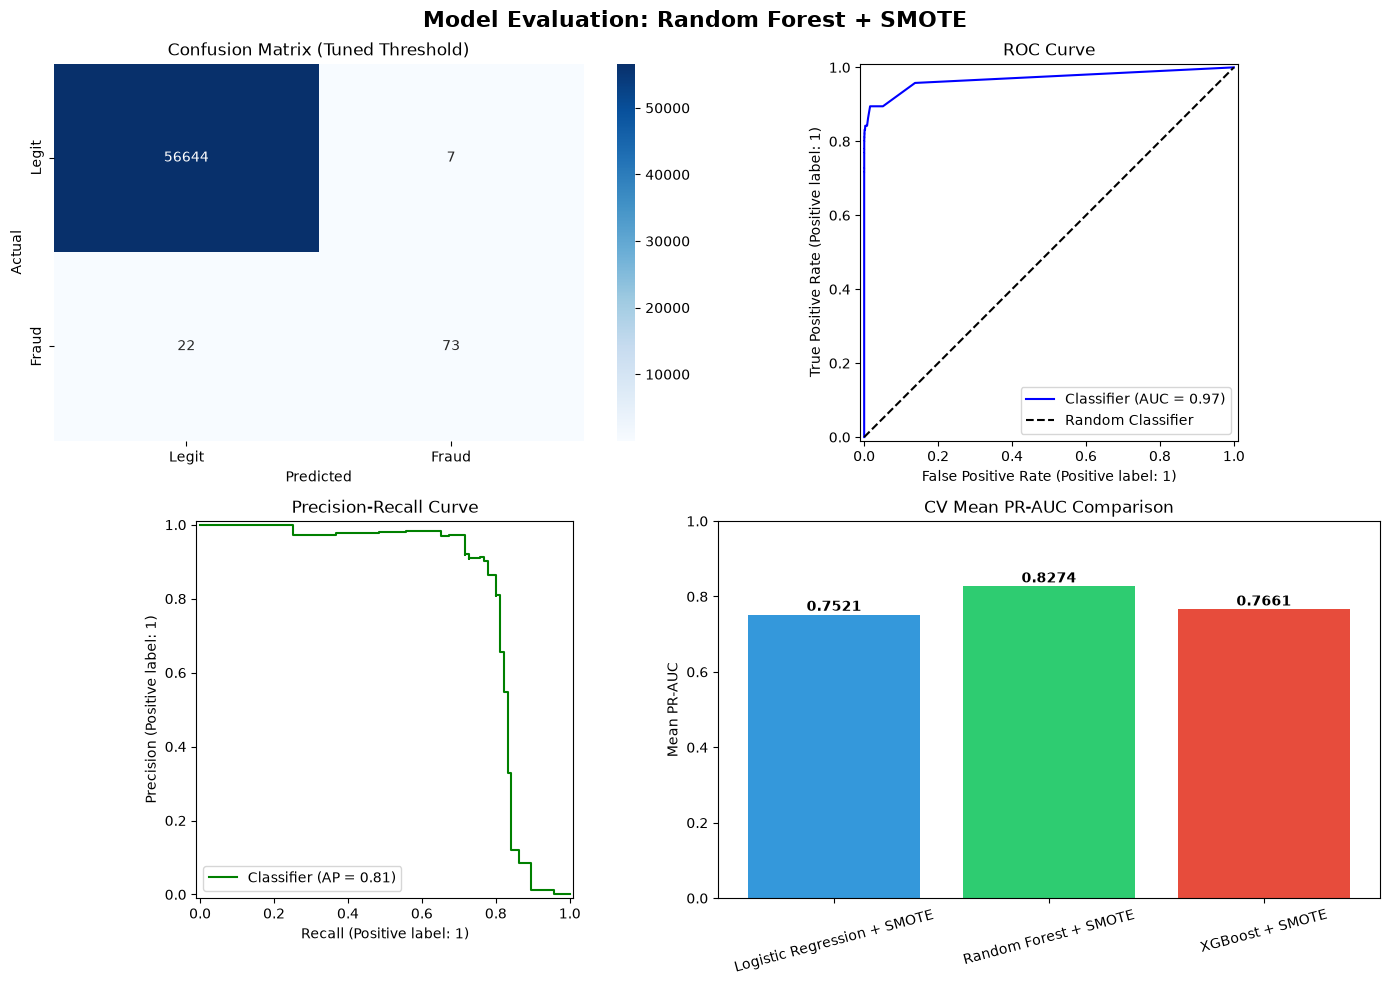

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Model Evaluation: {best_name}', fontsize=16, fontweight='bold')

# ── 1. Confusion matrix ───────────────────────────────────────────────────────
ax1 = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
ax1.set_title('Confusion Matrix (Tuned Threshold)')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

# ── 2. ROC curve ──────────────────────────────────────────────────────────────
ax2 = axes[0, 1]
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax2, color='blue')
ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax2.set_title('ROC Curve')
ax2.legend()

# ── 3. Precision-Recall curve ─────────────────────────────────────────────────
ax3 = axes[1, 0]
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax3, color='green')
ax3.set_title('Precision-Recall Curve')

# ── 4. CV results comparison ──────────────────────────────────────────────────
ax4 = axes[1, 1]
model_names = list(cv_results.keys())
model_scores = list(cv_results.values())
bars = ax4.bar(model_names, model_scores, color=['#3498db', '#2ecc71', '#e74c3c'])
ax4.set_title('CV Mean PR-AUC Comparison')
ax4.set_ylabel('Mean PR-AUC')
ax4.set_ylim(0, 1)
for bar, score in zip(bars, model_scores):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', fontweight='bold')
ax4.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- The confusion matrix indicates that the model correctly classifies the vast majority of legitimate transactions while successfully identifying most fraudulent transactions.
- The ROC curve demonstrates strong discrimination capability, with an ROC-AUC close to 1.
- The Precision-Recall curve confirms that the classifier maintains a good balance between precision and recall despite the severe class imbalance.
- Cross-validation results show that the Random Forest pipeline achieved the highest average PR-AUC, making it the most suitable model for this dataset.

## 9. Conclusion

This project developed and evaluated multiple machine learning models for detecting fraudulent credit card transactions.

### Summary of the workflow

- Explored and analyzed the dataset using EDA.
- Verified data quality by checking missing values and duplicate records.
- Applied feature scaling and SMOTE within machine learning pipelines to address class imbalance while preventing data leakage.
- Compared Logistic Regression, Random Forest, and XGBoost using Stratified Cross-Validation.
- Selected the best-performing model based on the Average Precision (PR-AUC) score.
- Evaluated the selected model on an unseen test set using multiple performance metrics.

### Final Results

- Best Model: **Random Forest + SMOTE**
- Cross-Validation PR-AUC: **0.8274**
- Test ROC-AUC: **0.9694**
- Test PR-AUC: **0.8115**

### Key Findings

- The Random Forest pipeline achieved the strongest overall performance among the evaluated models.
- PR-AUC proved to be a more informative evaluation metric than accuracy because of the severe class imbalance.
- Combining feature scaling, SMOTE, and ensemble learning produced a robust fraud detection model capable of identifying fraudulent transactions with high precision and recall.

### Future Work

Potential improvements include:

- Hyperparameter optimization using GridSearchCV or Optuna.
- Cost-sensitive learning approaches.
- Threshold optimization for maximizing recall or precision.
- Explainability using SHAP or feature importance analysis.